# Step 2. 전처리 + 피처 엔지니어링 + 탐색적 분석

| 항목 | 내용 |
|------|------|
| **분석 기간** | 2016-01-01 ~ 2025-12-31 |
| **포트폴리오 자산** | 30종 (ETF 22 + 개별주 8) |
| **외부 지표** | 12종 (원자재·VIX·달러·암호화폐) |
| **FRED 매크로** | 8종 (금리·스프레드·고용·성장) |
| **파생 변수** | 15개 Feature Engineering |
| **최종 산출물** | df_reg_v2.csv (확장 회귀 데이터셋) |

In [2]:
# ── Imports & Data Loading ──────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings, os, pathlib

warnings.filterwarnings('ignore')
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 120

BASE = pathlib.Path('.')
DATA = BASE / 'data'
IMG  = BASE / 'images'
IMG.mkdir(exist_ok=True)

# 데이터 로드
portfolio_prices = pd.read_csv(DATA / 'portfolio_prices.csv', index_col=0, parse_dates=True)
external_prices  = pd.read_csv(DATA / 'external_prices.csv',  index_col=0, parse_dates=True)
fred_data        = pd.read_csv(DATA / 'fred_data.csv',        index_col=0, parse_dates=True)

print(f'portfolio_prices : {portfolio_prices.shape}')
print(f'external_prices  : {external_prices.shape}')
print(f'fred_data        : {fred_data.shape}')

# ── 자산 그룹 정의 ──
INDEX_ETF  = ['SPY', 'QQQ', 'IWM', 'EFA', 'EEM']
BOND_ETF   = ['TLT', 'AGG', 'SHY', 'TIP']
ALT_ETF    = ['GLD', 'DBC']
SECTOR_ETF = ['XLK', 'XLF', 'XLE', 'XLV', 'VOX', 'XLY', 'XLP', 'XLI', 'XLU', 'XLRE', 'XLB']
STOCKS     = ['AAPL', 'MSFT', 'AMZN', 'GOOGL', 'JPM', 'JNJ', 'PG', 'XOM']

EQUITY_TICKERS = INDEX_ETF + SECTOR_ETF + STOCKS  # 24 items
ALL_TICKERS    = INDEX_ETF + BOND_ETF + ALT_ETF + SECTOR_ETF + STOCKS  # 30 items

print(f'\nEQUITY_TICKERS : {len(EQUITY_TICKERS)}개')
print(f'ALL_TICKERS    : {len(ALL_TICKERS)}개')

portfolio_prices : (2609, 30)
external_prices  : (2609, 12)
fred_data        : (2609, 8)

EQUITY_TICKERS : 24개
ALL_TICKERS    : 30개


## 2-1. 수익률 계산

- **포트폴리오 30종**: 로그 수익률 `ln(P_t / P_{t-1})` 사용 → 시계열 합산 가능, 정규성 근사
- **외부 지표 12종**: 로그 수익률 동일 적용
  - 단, **VIX 계열(`^VIX`, `^VIX9D`, `^VIX3M`, `^VIX6M`)**: 이미 % 단위 수준 변수이므로 `.diff()` (수준 차분) 사용
- **FRED 매크로**: 수준 변수 그대로 유지 (금리·스프레드는 비율 자체가 의미)

In [3]:
# ── 2-1. 수익률 계산 ──────────────────────────────────────────

# (1) 포트폴리오 로그 수익률
port_ret = np.log(portfolio_prices / portfolio_prices.shift(1)).dropna()
print(f'포트폴리오 로그 수익률 : {port_ret.shape}')

# (2) 외부 지표 수익률 — VIX 계열은 수준 차분
VIX_COLS = [c for c in external_prices.columns if 'VIX' in c.upper()]
NON_VIX  = [c for c in external_prices.columns if c not in VIX_COLS]

ext_ret_logpart = np.log(external_prices[NON_VIX] / external_prices[NON_VIX].shift(1))
ext_ret_vixpart = external_prices[VIX_COLS].diff()
ext_ret = pd.concat([ext_ret_logpart, ext_ret_vixpart], axis=1).dropna()

print(f'외부 지표 수익률     : {ext_ret.shape}')
print(f'  - VIX 차분 컬럼   : {VIX_COLS}')
print(f'  - 로그 수익률 컬럼 : {NON_VIX}')

포트폴리오 로그 수익률 : (2608, 30)
외부 지표 수익률     : (2606, 12)
  - VIX 차분 컬럼   : ['^VIX', '^VIX9D', '^VIX3M', '^VIX6M']
  - 로그 수익률 컬럼 : ['CL=F', 'GC=F', 'SI=F', 'BTC-USD', 'ETH-USD', 'DX-Y.NYB', '^SKEW', 'HG=F']


## 2-2. 15개 파생 변수 생성 (Feature Engineering)

| # | 변수명 | 수식 / 설명 | 카테고리 |
|---|--------|------------|----------|
| 1 | `VIX_contango` | `^VIX3M / ^VIX - 1` | 변동성 기간구조 |
| 2 | `VIX_slope_9d_3m` | `^VIX3M - ^VIX9D` | VIX 단기 기울기 |
| 3 | `VIX_slope_3m_6m` | `^VIX6M - ^VIX3M` | VIX 장기 기울기 |
| 4 | `SKEW_level` | `^SKEW` 원시값 | 테일 리스크 |
| 5 | `SKEW_zscore` | `(SKEW - 63일 MA) / 63일 σ` | SKEW 표준화 |
| 6 | `Cu_Au_ratio` | `HG=F / GC=F` | 경기 심리 지표 |
| 7 | `Cu_Au_ratio_chg` | `Cu_Au_ratio.pct_change(21)` | 구리/금 모멘텀 |
| 8 | `HY_spread` | `BAMLH0A0HYM2` | 신용 스프레드 |
| 9 | `HY_spread_chg` | `BAMLH0A0HYM2.diff(5)` | 스프레드 변화 |
| 10 | `yield_curve` | `T10Y2Y` | 수익률 곡선 |
| 11 | `yield_curve_inv` | `(T10Y2Y < 0).astype(int)` | 역전 더미 |
| 12 | `claims_4wma` | `ICSA.rolling(20).mean()` | 실업 4주 이동평균 |
| 13 | `claims_zscore` | `(ICSA - 260일 MA) / 260일 σ` | 실업 표준화 |
| 14 | `WEI_level` | `WEI` | 주간 경제 지수 |
| 15 | `sahm_indicator` | `SAHMREALTIME` | Sahm 경기침체 지표 |

In [ ]:
# ── 2-2. 15개 파생 변수 생성 ─────────────────────────────────
feat = pd.DataFrame(index=portfolio_prices.index)

# 변동성 기간구조
feat['VIX_contango']     = external_prices['^VIX3M'] / external_prices['^VIX'] - 1
feat['VIX_slope_9d_3m']  = external_prices['^VIX3M'] - external_prices['^VIX9D']
feat['VIX_slope_3m_6m']  = external_prices['^VIX6M'] - external_prices['^VIX3M']

# 테일 리스크
feat['SKEW_level']  = external_prices['^SKEW']
skew_roll = external_prices['^SKEW'].rolling(63)
feat['SKEW_zscore'] = (external_prices['^SKEW'] - skew_roll.mean()) / skew_roll.std()

# 구리/금 경기 심리
feat['Cu_Au_ratio']     = external_prices['HG=F'] / external_prices['GC=F']
feat['Cu_Au_ratio_chg'] = feat['Cu_Au_ratio'].pct_change(21)

# 신용 스프레드
feat['HY_spread']     = fred_data['BAMLH0A0HYM2']
feat['HY_spread_chg'] = fred_data['BAMLH0A0HYM2'].diff(5)

# 수익률 곡선
feat['yield_curve']     = fred_data['T10Y2Y']
feat['yield_curve_inv'] = (fred_data['T10Y2Y'] < 0).astype(int)

# 고용 지표
feat['claims_4wma']  = fred_data['ICSA'].rolling(20).mean()
icsa_roll = fred_data['ICSA'].rolling(260)
feat['claims_zscore'] = (fred_data['ICSA'] - icsa_roll.mean()) / icsa_roll.std()

# 성장 지표
feat['WEI_level']      = fred_data['WEI']
feat['sahm_indicator'] = fred_data['SAHMREALTIME']

FEATURE_NAMES = list(feat.columns)
print(f'파생 변수 {len(FEATURE_NAMES)}개 생성 완료')
print(feat.tail(3))

# 저장
feat.to_csv(DATA / 'features.csv')
print(f'\n→ data/features.csv 저장 ({feat.shape})')

파생 변수 15개 생성 완료
            VIX_contango  VIX_slope_9d_3m  VIX_slope_3m_6m  SKEW_level  \
Date                                                                     
2025-12-29      0.254930             6.45         2.780001  150.470001   
2025-12-30      0.240056             6.31         2.920000  148.330002   
2025-12-31      0.240056             6.31         2.920000  148.330002   

            SKEW_zscore  Cu_Au_ratio  Cu_Au_ratio_chg  HY_spread  \
Date                                                               
2025-12-29     0.483268     0.001269         0.032672       2.87   
2025-12-30     0.115920     0.001311         0.064586       2.84   
2025-12-31     0.106274     0.001311         0.063167       2.81   

            HY_spread_chg  yield_curve  yield_curve_inv  claims_4wma  \
Date                                                                   
2025-12-29          -0.01         0.67                0     221850.0   
2025-12-30           0.01         0.69                0 

'\n→ data/features.csv 저장 ((2609, 15))'

## 2-3. df_reg_v2 구축 (확장 회귀 데이터셋)

- **종속변수**: `rv_neutral` = 동일가중(1/30) 포트폴리오 일일 수익률 → 21일 롤링 표준편차 × √252 (연환산)
- **독립변수**: 외부 수익률 + 외부 롤링 변동성(21일) + VIX 수준 + FRED 매크로 + 15개 파생변수

In [5]:
# ── 2-3. df_reg_v2 구축 ──────────────────────────────────────

# (1) 종속변수: 동일가중 포트폴리오 실현변동성
ew_ret = port_ret.mean(axis=1)  # 1/30 동일가중
rv_neutral = ew_ret.rolling(21).std() * np.sqrt(252)
rv_neutral.name = 'rv_neutral'

# (2) 외부 수익률 (이미 계산)
ext_ret_aligned = ext_ret.reindex(portfolio_prices.index)

# (3) 외부 롤링 변동성 (21일)
ext_vol = ext_ret_aligned.rolling(21).std() * np.sqrt(252)
ext_vol.columns = [c + '_vol21' for c in ext_vol.columns]

# (4) VIX 수준
vix_level = external_prices['^VIX'].reindex(portfolio_prices.index)
vix_level.name = 'VIX_level'

# (5) FRED 매크로 선별
fred_macro = pd.DataFrame(index=portfolio_prices.index)
fred_macro['DGS10']   = fred_data['DGS10']
fred_macro['CPI_MoM'] = fred_data['CPIAUCSL'].pct_change() * 100
fred_macro['UNRATE']  = fred_data['UNRATE']

# (6) 통합
df_reg_v2 = pd.concat([
    rv_neutral,
    ext_ret_aligned,
    ext_vol,
    vix_level,
    fred_macro,
    feat
], axis=1).dropna()

# 저장
df_reg_v2.to_csv(DATA / 'df_reg_v2.csv')
print(f'df_reg_v2 shape : {df_reg_v2.shape}')
print(f'컬럼 수         : {len(df_reg_v2.columns)}개')
print(f'기간            : {df_reg_v2.index[0].date()} ~ {df_reg_v2.index[-1].date()}')
print(f'\n→ data/df_reg_v2.csv 저장 완료')

df_reg_v2 shape : (2328, 44)
컬럼 수         : 44개
기간            : 2016-12-29 ~ 2025-12-31

→ data/df_reg_v2.csv 저장 완료


## 2-4. EDA 시각화

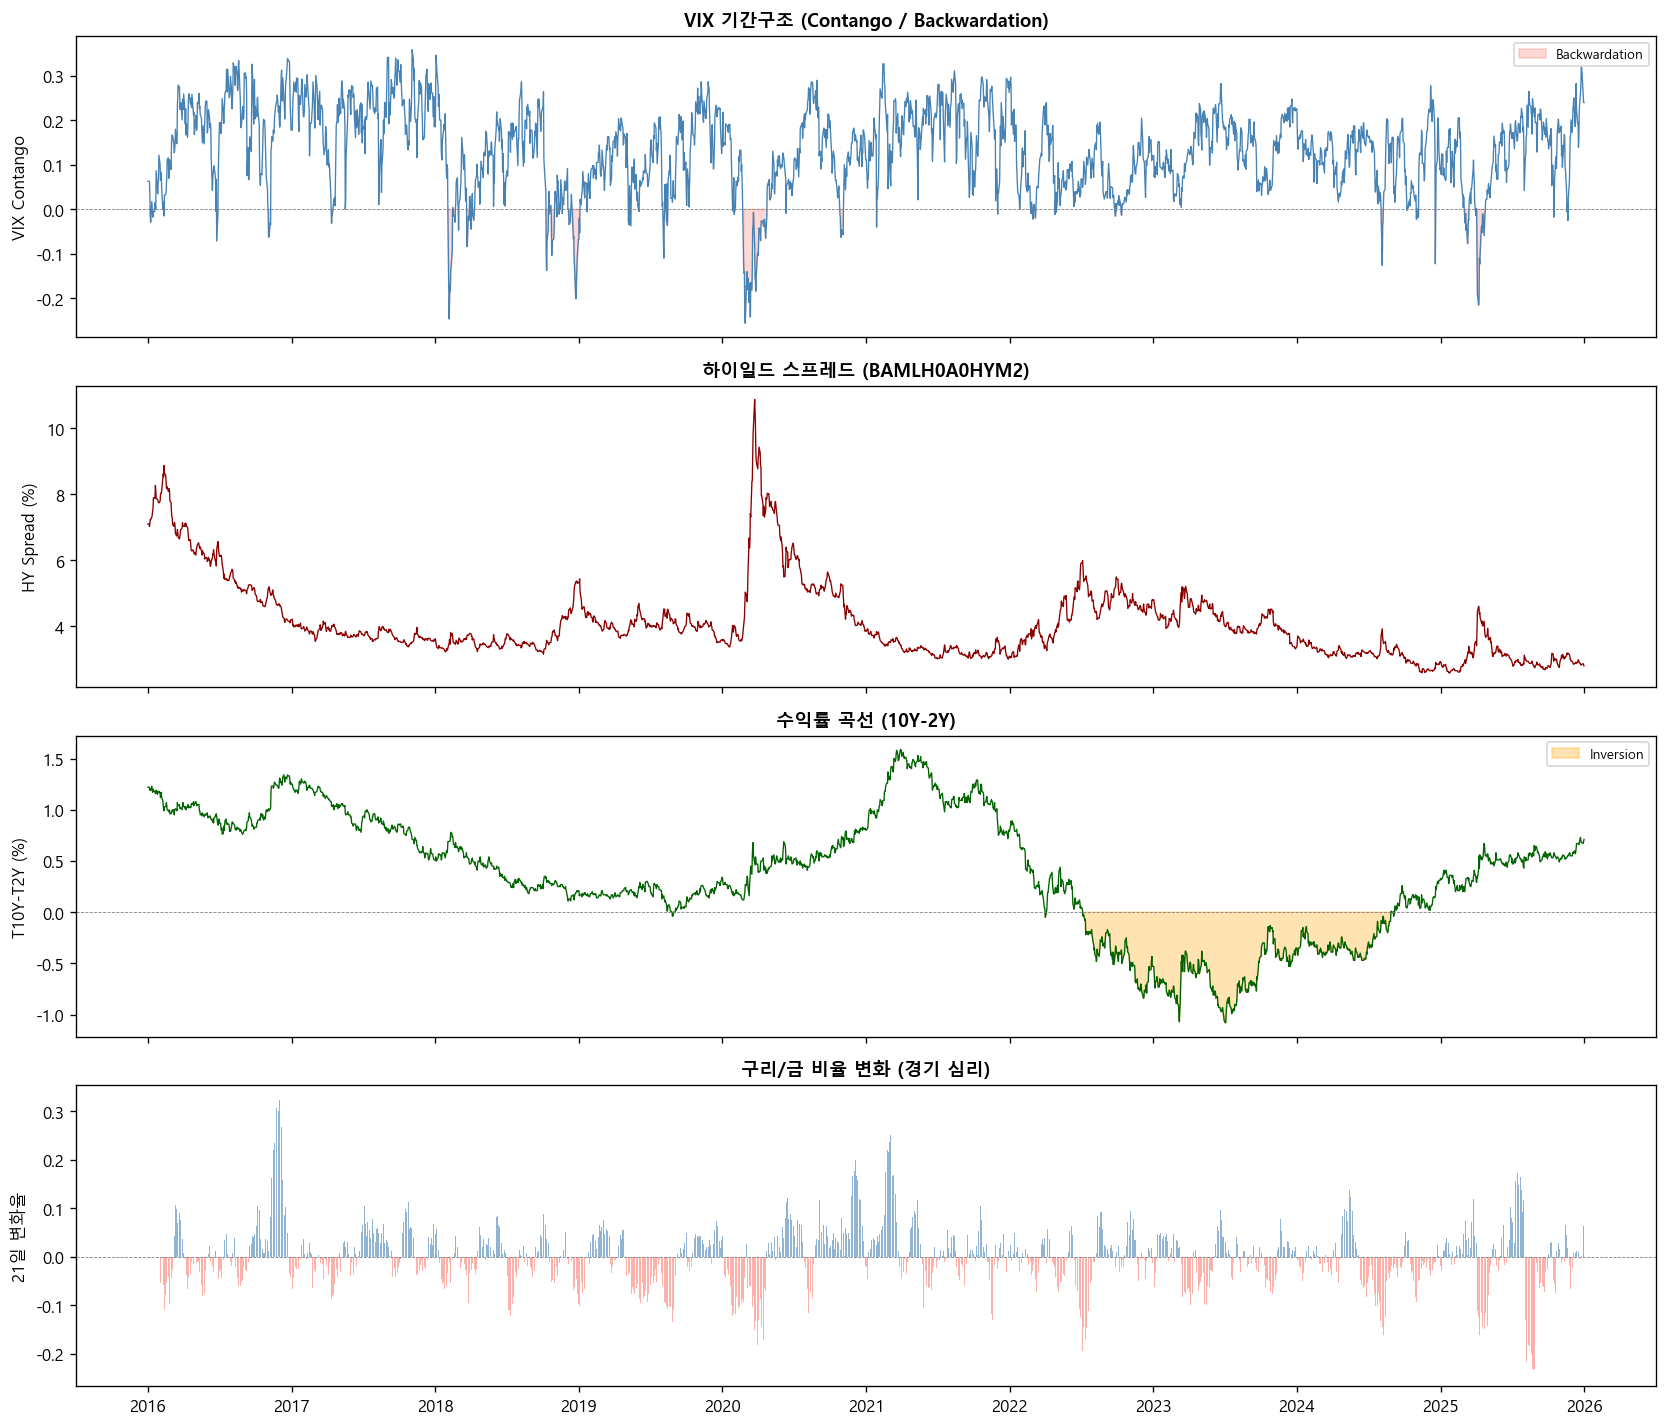

→ images/step2_01_dashboard.png 저장 완료


In [6]:
# ── Viz 1: 대안데이터 시계열 대시보드 (4-panel) ─────────────────
fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

# (a) VIX Contango + 백워데이션 영역
ax = axes[0]
contango = feat['VIX_contango'].dropna()
ax.plot(contango.index, contango.values, color='steelblue', lw=0.8)
ax.fill_between(contango.index, contango.values, 0,
                where=contango.values < 0, color='salmon', alpha=0.3, label='Backwardation')
ax.axhline(0, color='gray', ls='--', lw=0.5)
ax.set_ylabel('VIX Contango')
ax.set_title('VIX 기간구조 (Contango / Backwardation)', fontsize=11, fontweight='bold')
ax.legend(loc='upper right', fontsize=8)

# (b) HY Spread
ax = axes[1]
hy = feat['HY_spread'].dropna()
ax.plot(hy.index, hy.values, color='darkred', lw=0.8)
ax.set_ylabel('HY Spread (%)')
ax.set_title('하이일드 스프레드 (BAMLH0A0HYM2)', fontsize=11, fontweight='bold')

# (c) Yield Curve + Inversion 영역
ax = axes[2]
yc = feat['yield_curve'].dropna()
ax.plot(yc.index, yc.values, color='darkgreen', lw=0.8)
ax.fill_between(yc.index, yc.values, 0,
                where=yc.values < 0, color='orange', alpha=0.3, label='Inversion')
ax.axhline(0, color='gray', ls='--', lw=0.5)
ax.set_ylabel('T10Y-T2Y (%)')
ax.set_title('수익률 곡선 (10Y-2Y)', fontsize=11, fontweight='bold')
ax.legend(loc='upper right', fontsize=8)

# (d) Cu/Au Ratio Change
ax = axes[3]
ca = feat['Cu_Au_ratio_chg'].dropna()
ax.bar(ca.index, ca.values, width=1, color=np.where(ca.values >= 0, 'steelblue', 'salmon'), alpha=0.6)
ax.axhline(0, color='gray', ls='--', lw=0.5)
ax.set_ylabel('21일 변화율')
ax.set_title('구리/금 비율 변화 (경기 심리)', fontsize=11, fontweight='bold')

plt.tight_layout()
fig.savefig(IMG / 'step2_01_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('→ images/step2_01_dashboard.png 저장 완료')

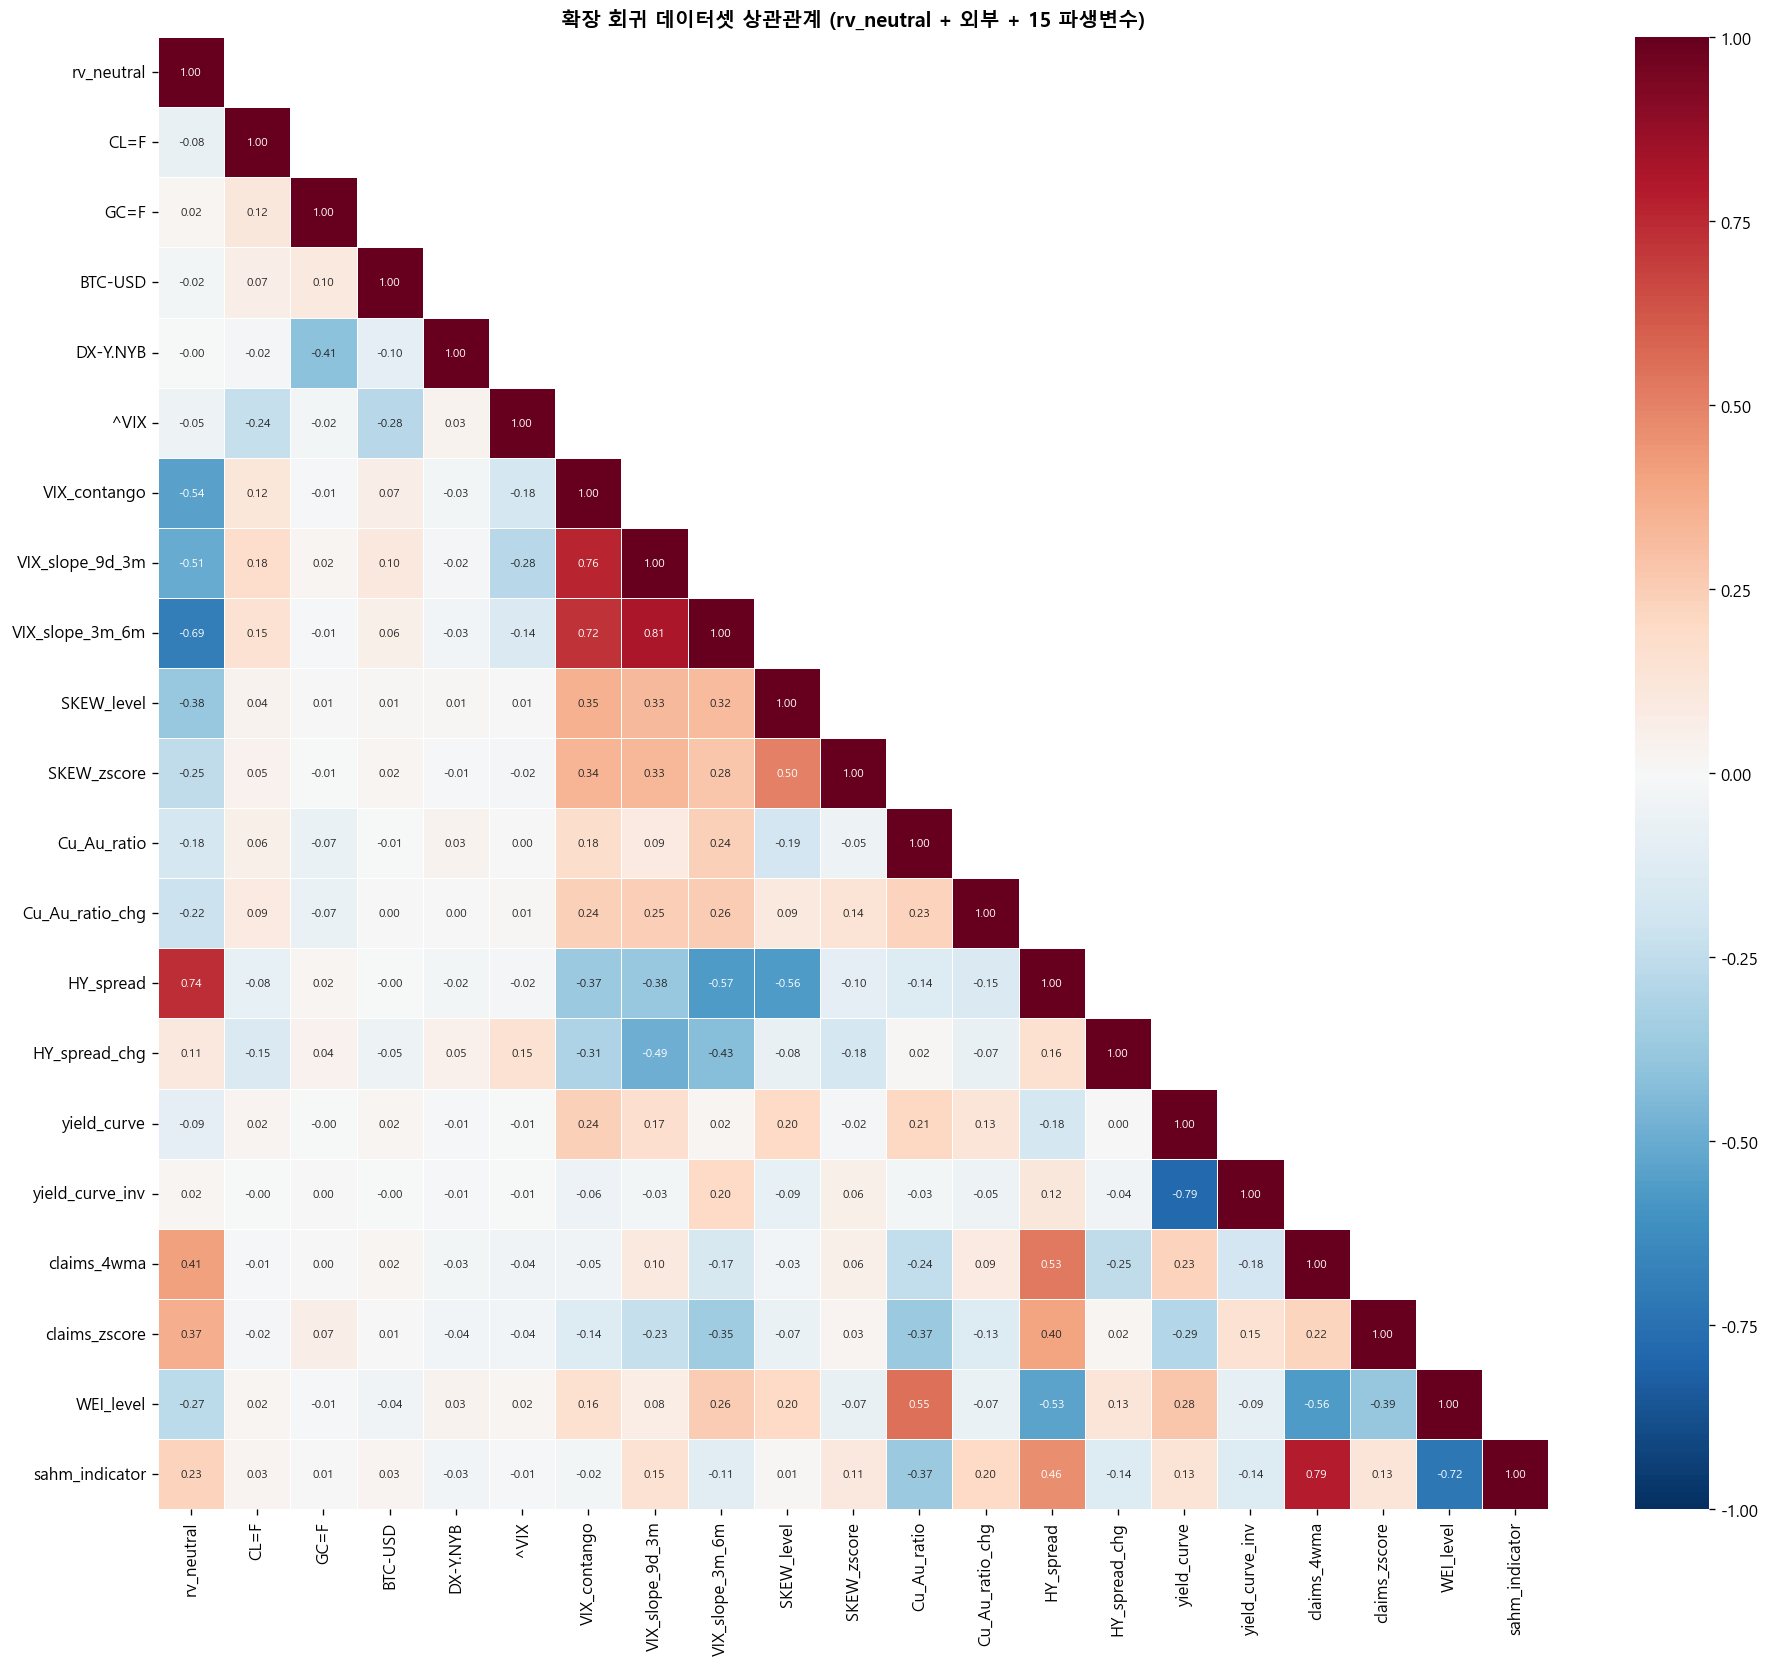

→ images/step2_02_correlation.png 저장 완료


In [7]:
# ── Viz 2: 확장 상관관계 히트맵 ─────────────────────────────────
# ~20개 핵심 컬럼 선택
heatmap_cols = (
    ['rv_neutral']
    + ['CL=F', 'GC=F', 'BTC-USD', 'DX-Y.NYB', '^VIX']  # 외부 수익률
    + FEATURE_NAMES  # 15개 파생 변수
)
# df_reg_v2에 존재하는 컬럼만
heatmap_cols = [c for c in heatmap_cols if c in df_reg_v2.columns]

corr = df_reg_v2[heatmap_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(16, 14))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, linewidths=0.3,
            annot_kws={'size': 7}, ax=ax)
ax.set_title('확장 회귀 데이터셋 상관관계 (rv_neutral + 외부 + 15 파생변수)', fontsize=12, fontweight='bold')
plt.tight_layout()
fig.savefig(IMG / 'step2_02_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print('→ images/step2_02_correlation.png 저장 완료')

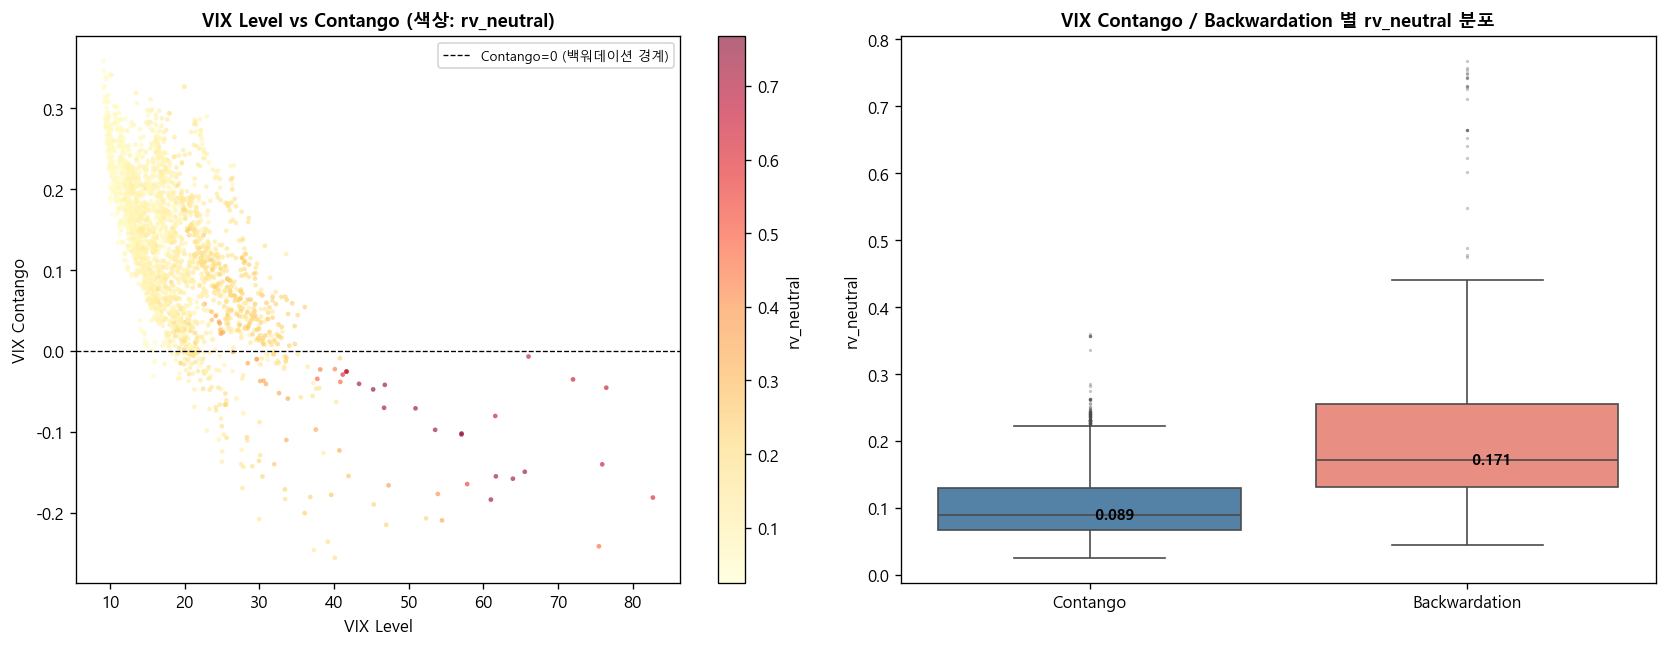

→ images/step2_03_vix_contango.png 저장 완료


In [8]:
# ── Viz 3: VIX level vs VIX contango scatter + boxplot ─────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# Scatter
ax = axes[0]
valid = df_reg_v2[['VIX_level', 'VIX_contango', 'rv_neutral']].dropna()
sc = ax.scatter(valid['VIX_level'], valid['VIX_contango'],
                c=valid['rv_neutral'], cmap='YlOrRd', s=8, alpha=0.6, edgecolors='none')
ax.axhline(0, color='black', ls='--', lw=0.8, label='Contango=0 (백워데이션 경계)')
ax.set_xlabel('VIX Level')
ax.set_ylabel('VIX Contango')
ax.set_title('VIX Level vs Contango (색상: rv_neutral)', fontsize=11, fontweight='bold')
ax.legend(fontsize=8)
plt.colorbar(sc, ax=ax, label='rv_neutral')

# Boxplot: Contango vs Backwardation → rv_neutral
ax = axes[1]
valid['regime'] = np.where(valid['VIX_contango'] >= 0, 'Contango', 'Backwardation')
order = ['Contango', 'Backwardation']
palette = {'Contango': 'steelblue', 'Backwardation': 'salmon'}
sns.boxplot(data=valid, x='regime', y='rv_neutral', order=order, palette=palette, ax=ax,
            flierprops=dict(marker='.', markersize=2, alpha=0.3))
ax.set_title('VIX Contango / Backwardation 별 rv_neutral 분포', fontsize=11, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('rv_neutral')

# 중앙값 표시
for i, regime in enumerate(order):
    med = valid[valid['regime'] == regime]['rv_neutral'].median()
    ax.text(i, med, f' {med:.3f}', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
fig.savefig(IMG / 'step2_03_vix_contango.png', dpi=150, bbox_inches='tight')
plt.show()
print('→ images/step2_03_vix_contango.png 저장 완료')

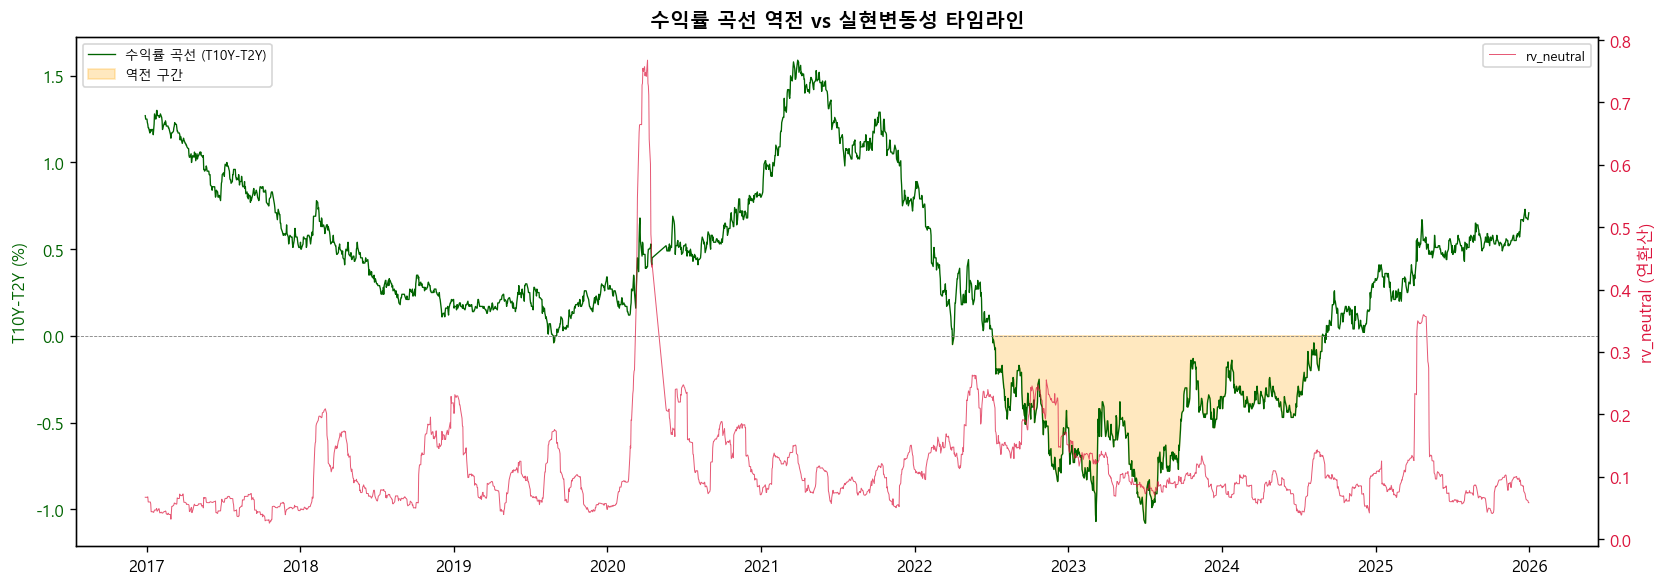

→ images/step2_04_yield_curve.png 저장 완료


In [9]:
# ── Viz 4: 수익률 곡선 역전 타임라인 ────────────────────────────
fig, ax1 = plt.subplots(figsize=(14, 5))

yc = df_reg_v2['yield_curve'].dropna()
rv = df_reg_v2['rv_neutral'].dropna()

# Yield curve
ax1.plot(yc.index, yc.values, color='darkgreen', lw=0.8, label='수익률 곡선 (T10Y-T2Y)')
ax1.fill_between(yc.index, yc.values, 0,
                 where=yc.values < 0, color='orange', alpha=0.25, label='역전 구간')
ax1.axhline(0, color='gray', ls='--', lw=0.5)
ax1.set_ylabel('T10Y-T2Y (%)', color='darkgreen')
ax1.tick_params(axis='y', labelcolor='darkgreen')
ax1.legend(loc='upper left', fontsize=8)

# rv_neutral overlay
ax2 = ax1.twinx()
ax2.plot(rv.index, rv.values, color='crimson', lw=0.6, alpha=0.7, label='rv_neutral')
ax2.set_ylabel('rv_neutral (연환산)', color='crimson')
ax2.tick_params(axis='y', labelcolor='crimson')
ax2.legend(loc='upper right', fontsize=8)

ax1.set_title('수익률 곡선 역전 vs 실현변동성 타임라인', fontsize=12, fontweight='bold')
plt.tight_layout()
fig.savefig(IMG / 'step2_04_yield_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print('→ images/step2_04_yield_curve.png 저장 완료')

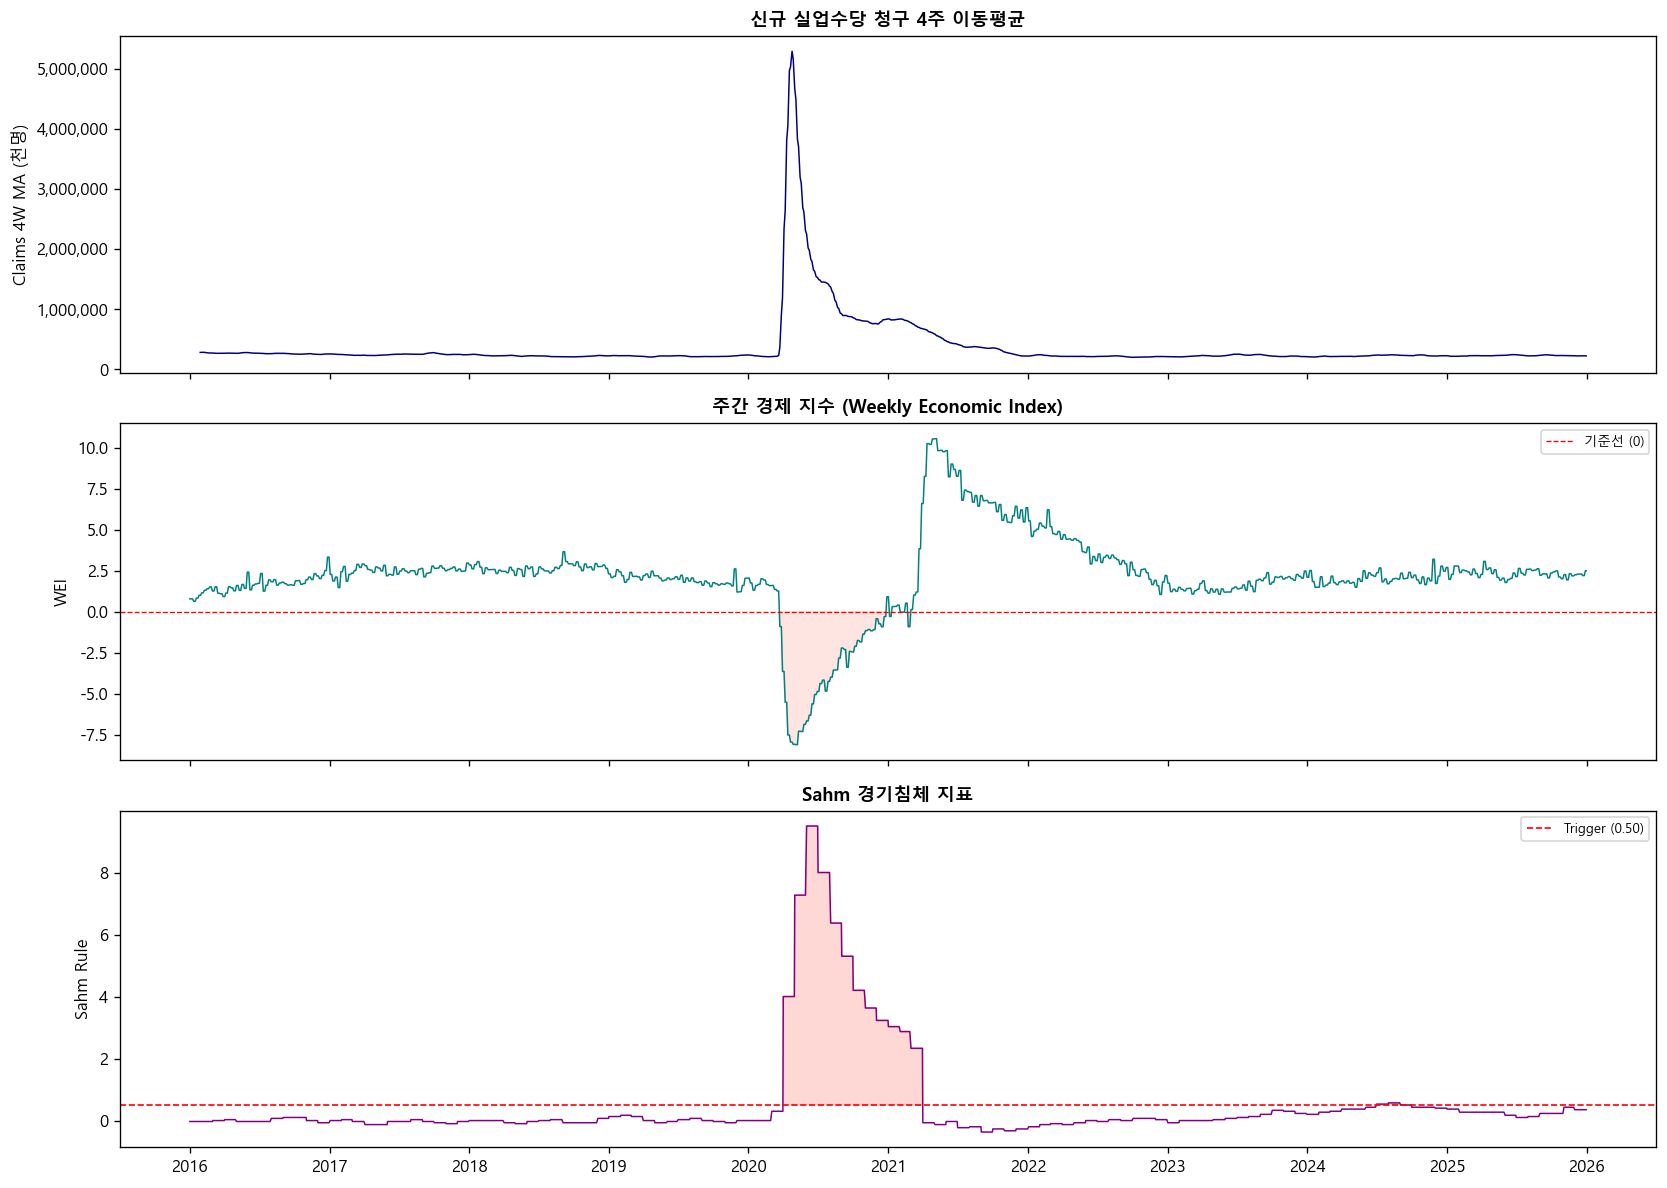

→ images/step2_05_macro_nowcast.png 저장 완료


In [10]:
# ── Viz 5: 주간 매크로 Nowcasting (3-panel) ─────────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# (a) 실업수당 4주 이동평균
ax = axes[0]
cl = feat['claims_4wma'].dropna()
ax.plot(cl.index, cl.values, color='navy', lw=0.9)
ax.set_ylabel('Claims 4W MA (천명)')
ax.set_title('신규 실업수당 청구 4주 이동평균', fontsize=11, fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# (b) WEI
ax = axes[1]
wei = feat['WEI_level'].dropna()
ax.plot(wei.index, wei.values, color='teal', lw=0.9)
ax.axhline(0, color='red', ls='--', lw=0.8, label='기준선 (0)')
ax.fill_between(wei.index, wei.values, 0,
                where=wei.values < 0, color='salmon', alpha=0.2)
ax.set_ylabel('WEI')
ax.set_title('주간 경제 지수 (Weekly Economic Index)', fontsize=11, fontweight='bold')
ax.legend(fontsize=8)

# (c) Sahm Indicator
ax = axes[2]
sahm = feat['sahm_indicator'].dropna()
ax.plot(sahm.index, sahm.values, color='purple', lw=0.9)
ax.axhline(0.50, color='red', ls='--', lw=1.0, label='Trigger (0.50)')
ax.fill_between(sahm.index, sahm.values, 0.50,
                where=sahm.values >= 0.50, color='salmon', alpha=0.3)
ax.set_ylabel('Sahm Rule')
ax.set_title('Sahm 경기침체 지표', fontsize=11, fontweight='bold')
ax.legend(fontsize=8)

plt.tight_layout()
fig.savefig(IMG / 'step2_05_macro_nowcast.png', dpi=150, bbox_inches='tight')
plt.show()
print('→ images/step2_05_macro_nowcast.png 저장 완료')

## 2-5. Granger 인과 검정

Granger 인과 검정은 **"X의 과거값이 Y 예측에 통계적으로 유의미한 정보를 추가하는가?"**를 검증합니다.

- H₀: X는 Y를 Granger-cause하지 않는다
- H₁: X는 Y를 Granger-cause한다
- **대상**: df_reg_v2의 모든 수치형 변수 → `rv_neutral`
- **최대 시차**: 10일 (`maxlag=10`)
- 각 변수별로 1~10 lag의 F-test p-value 중 **최소 p-value**와 해당 lag 추출

In [11]:
# ── 2-5. Granger 인과 검정 ───────────────────────────────────
from statsmodels.tsa.stattools import grangercausalitytests

target = 'rv_neutral'
candidates = [c for c in df_reg_v2.select_dtypes(include=[np.number]).columns if c != target]

results = []
for col in candidates:
    sub = df_reg_v2[[target, col]].dropna()
    if len(sub) < 50:
        continue
    try:
        gc = grangercausalitytests(sub, maxlag=10, verbose=False)
        pvals = {lag: gc[lag][0]['ssr_ftest'][1] for lag in range(1, 11)}
        best_lag = min(pvals, key=pvals.get)
        min_p = pvals[best_lag]
        results.append({'variable': col, 'best_lag': best_lag, 'p_value': min_p})
    except Exception:
        pass

granger_df = pd.DataFrame(results).sort_values('p_value').reset_index(drop=True)
granger_df['significant'] = granger_df['p_value'] < 0.05
granger_df.to_csv(DATA / 'granger_results.csv', index=False)

print(f'Granger 검정 완료: {len(granger_df)}개 변수')
print(f'유의미 (p < 0.05): {granger_df["significant"].sum()}개')
print(f'\n→ data/granger_results.csv 저장 완료')
print('\n── Top 20 ──')
print(granger_df.head(20).to_string(index=False))

Granger 검정 완료: 43개 변수
유의미 (p < 0.05): 34개

→ data/granger_results.csv 저장 완료

── Top 20 ──
       variable  best_lag      p_value  significant
  HY_spread_chg         1 7.208402e-65         True
VIX_slope_9d_3m         1 1.862704e-60         True
      VIX_level         1 1.357032e-47         True
VIX_slope_3m_6m         1 5.988865e-43         True
    claims_4wma         2 4.911668e-34         True
      HY_spread         6 1.567544e-32         True
   VIX_contango         1 1.611131e-24         True
     CL=F_vol21         9 1.707281e-24         True
         UNRATE        10 1.976638e-23         True
  BTC-USD_vol21         7 1.654706e-13         True
         ^VIX6M        10 2.862817e-13         True
           ^VIX        10 8.375161e-13         True
  ETH-USD_vol21         7 3.683083e-12         True
         ^VIX3M        10 1.209118e-11         True
         ^VIX9D        10 2.169757e-11         True
 sahm_indicator        10 2.709309e-11         True
   ^VIX9D_vol21         1 

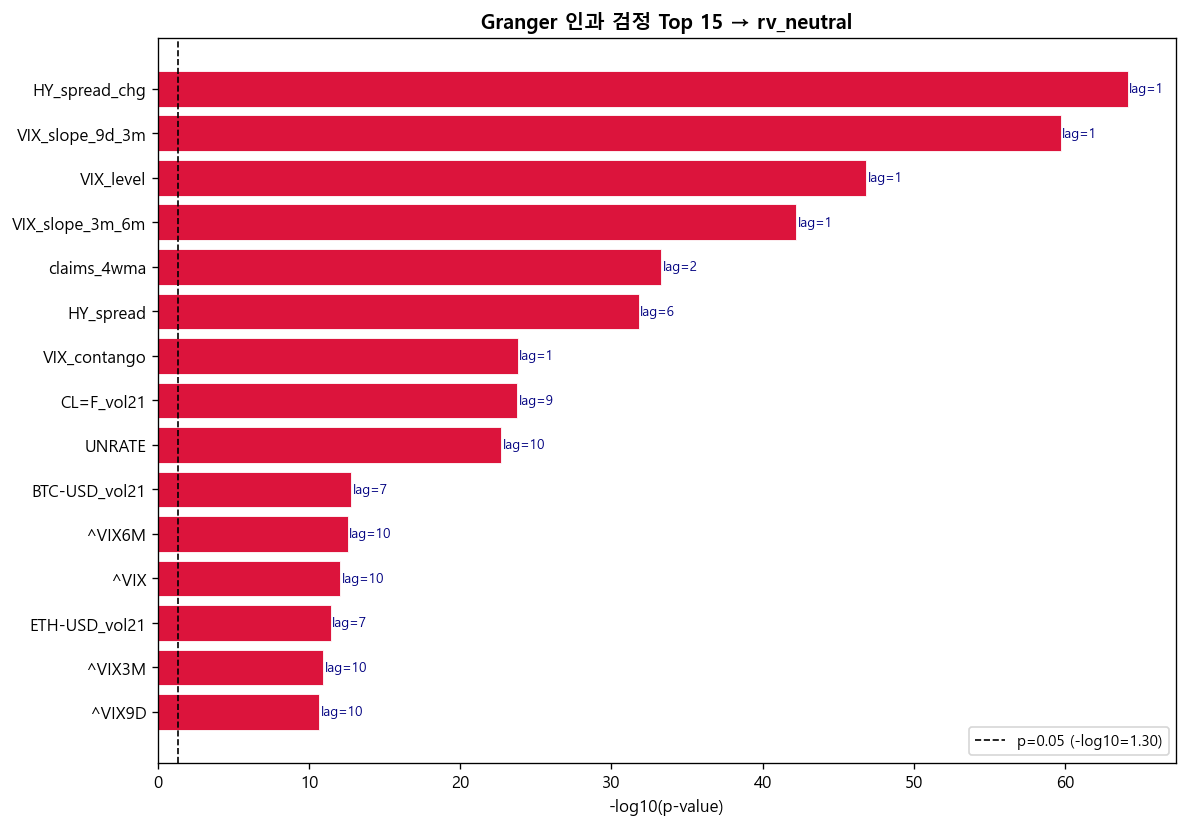

→ images/step2_06_granger.png 저장 완료


In [12]:
# ── Viz 6: Granger Top 15 수평 막대 ─────────────────────────────
top15 = granger_df.head(15).copy()
top15['-log10(p)'] = -np.log10(top15['p_value'].clip(lower=1e-300))
top15 = top15.sort_values('-log10(p)', ascending=True)  # 높은 것이 위

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['crimson' if p < 0.05 else 'gray' for p in top15['p_value']]
ax.barh(top15['variable'], top15['-log10(p)'], color=colors, edgecolor='white', linewidth=0.5)

# 유의 기준선
sig_line = -np.log10(0.05)
ax.axvline(sig_line, color='black', ls='--', lw=1, label=f'p=0.05 (-log10={sig_line:.2f})')

ax.set_xlabel('-log10(p-value)', fontsize=10)
ax.set_title('Granger 인과 검정 Top 15 → rv_neutral', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)

# lag 표시
for i, (_, row) in enumerate(top15.iterrows()):
    ax.text(row['-log10(p)'] + 0.1, i, f"lag={int(row['best_lag'])}",
            va='center', fontsize=8, color='navy')

plt.tight_layout()
fig.savefig(IMG / 'step2_06_granger.png', dpi=150, bbox_inches='tight')
plt.show()
print('→ images/step2_06_granger.png 저장 완료')

In [13]:
# ── 최종 요약 ────────────────────────────────────────────────
import glob

imgs = sorted(glob.glob(str(IMG / 'step2_*.png')))

print('=' * 60)
print('  Step 2 전처리 + 피처 엔지니어링 + EDA 완료')
print('=' * 60)
print(f'  df_reg_v2 shape    : {df_reg_v2.shape[0]:,} rows × {df_reg_v2.shape[1]} cols')
print(f'  파생 변수          : {len(FEATURE_NAMES)}개')
print(f'  Granger 유의 변수  : {granger_df["significant"].sum()}개 / {len(granger_df)}개 (p < 0.05)')
print(f'  저장 이미지        : {len(imgs)}개')
for img in imgs:
    print(f'    - {os.path.basename(img)}')
print('=' * 60)

  Step 2 전처리 + 피처 엔지니어링 + EDA 완료
  df_reg_v2 shape    : 2,328 rows × 44 cols
  파생 변수          : 15개
  Granger 유의 변수  : 34개 / 43개 (p < 0.05)
  저장 이미지        : 6개
    - step2_01_dashboard.png
    - step2_02_correlation.png
    - step2_03_vix_contango.png
    - step2_04_yield_curve.png
    - step2_05_macro_nowcast.png
    - step2_06_granger.png
